# Hybrid Scam Detection  
### A Comparative Computational Linguistics Approach  

**ENG 685 Final Project**  
Jashona Young  

---

## Overview

This project evaluates three approaches to detecting scam and phishing language across SMS and email communication:

- Rule-based symbolic linguistic system  
- BERT-based contextual model  
- Hybrid system combining both approaches  

The goal is to compare performance, interpretability, and linguistic coverage across these frameworks, while grounding the work in symbolic computational linguistics.

Across SMS and Email Communication Contexts

This broader scope allows the analysis to capture general patterns of deceptive language rather than restricting the study to a single domain.

## 1. Introduction

Deceptive digital communication, including spam messages and phishing emails, continues to be a major challenge across modern communication platforms. These messages often rely on linguistic strategies such as urgency, impersonation, reward-based persuasion, and requests for sensitive information in order to manipulate users.

This project explores how different computational approaches can be used to detect scam and phishing language across SMS and email communication contexts. Specifically, it compares three models:

- a rule-based symbolic linguistic system  
- a BERT-based contextual model  
- a hybrid model combining both approaches  

The rule-based model focuses on explicit linguistic patterns, offering interpretability and transparency. The BERT-based model captures broader contextual meaning, allowing it to detect more subtle forms of deception. The hybrid model attempts to combine these strengths to improve overall performance.

The models are evaluated on a multi-source dataset of over 16,000 messages, including SMS spam, phishing emails, and smishing data. The goal is to compare performance, interpretability, and linguistic coverage across approaches, while highlighting the trade-offs between symbolic and neural methods in computational linguistics.

In [1]:
import pandas as pd
import numpy as np
import re
from pathlib import Path

from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
PROJECT_ROOT = Path("..").resolve()
print(PROJECT_ROOT)

/app


## 2. Data

In [3]:
df = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "combined_scam_dataset.csv")

df.head()

,text,label,source
0,"Go until jurong point, crazy.. Available only ...",legitimate,uci_sms_spam
1,Ok lar... Joking wif u oni...,legitimate,uci_sms_spam
2,Free entry in 2 a wkly comp to win FA Cup fina...,scam,uci_sms_spam
3,U dun say so early hor... U c already then say...,legitimate,uci_sms_spam
4,"Nah I don't think he goes to usf, he lives aro...",legitimate,uci_sms_spam


In [4]:
df["label"].value_counts()

label
legitimate    9066
scam          7217
Name: count, dtype: int64

## 3. Preprocessing

Before analysis, text data is normalized to improve consistency across models.

Preprocessing steps include:

- converting text to lowercase
- normalizing URLs
- removing extra whitespace

This process intentionally preserves scam-relevant language patterns such as keywords, commands, and structural cues instead of aggressively removing them.

In [5]:
def basic_clean_text(text):
    """Clean text while preserving scam-relevant patterns.

    Parameters
    ----------
    text : str
        Raw input text.

    Returns
    -------
    str
        Cleaned text.
    """
    if not isinstance(text, str):
        return ""

    cleaned = text.lower()
    cleaned = re.sub(r"https?://\S+|www\.\S+", " URL ", cleaned)
    cleaned = re.sub(r"\s+", " ", cleaned).strip()

    return cleaned

In [6]:
df["clean_text"] = df["text"].apply(basic_clean_text)

df[["text", "clean_text", "label"]]

,text,clean_text,label
0,"Go until jurong point, crazy.. Available only ...","go until jurong point, crazy.. available only ...",legitimate
1,Ok lar... Joking wif u oni...,ok lar... joking wif u oni...,legitimate
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in 2 a wkly comp to win fa cup fina...,scam
3,U dun say so early hor... U c already then say...,u dun say so early hor... u c already then say...,legitimate
4,"Nah I don't think he goes to usf, he lives aro...","nah i don't think he goes to usf, he lives aro...",legitimate
...,...,...,...
16278,Your monthly statement is now available in you...,your monthly statement is now available in you...,legitimate
16279,Your appointment confirmation has been updated.,your appointment confirmation has been updated.,legitimate
16280,Your package delivery status changed this morn...,your package delivery status changed this morn...,legitimate
16281,Your password was changed successfully.,your password was changed successfully.,legitimate


## 4. Rule-Based Linguistic Model

The rule-based model represents a symbolic computational linguistics approach. It uses explicitly defined linguistic patterns associated with  scam messages.

These include:

- urgency language
- impersonation cues
- wallet or credential requests
- guaranteed profit claims
- fear or loss framing

This model is highly interpretable because it directly shows which linguistic features triggered a classification.

In [7]:
SCAM_RULES = {
    "urgency": [
        "act now",
        "limited time",
        "last chance",
        "immediately",
        "urgent",
        "now",
        "today only",
        "expires",
        "final notice",
        "respond immediately",
    ],

    "reward_bait": [
        "congratulations",
        "you have won",
        "claim your prize",
        "free gift",
        "reward",
        "bonus",
        "selected winner",
        "cash prize",
        "gift card",
        "exclusive offer",
    ],

    "financial_manipulation": [
        "guaranteed returns",
        "risk free",
        "double your money",
        "profit guaranteed",
        "investment opportunity",
        "earn money",
        "quick cash",
        "loan approved",
        "payment failed",
        "billing information",
    ],

    "credential_request": [
        "verify your account",
        "confirm your identity",
        "reset your password",
        "update your password",
        "login now",
        "sign in",
        "account verification",
        "security check",
        "validate your account",
        "update your information",
    ],

    "impersonation_authority": [
        "official support",
        "customer support",
        "admin",
        "support agent",
        "compliance team",
        "security team",
        "fraud department",
        "account services",
        "bank notice",
        "service alert",
    ],

    "fear_loss": [
        "account suspended",
        "account locked",
        "funds at risk",
        "unauthorized activity",
        "suspicious activity",
        "avoid losing",
        "restricted account",
        "failed login attempt",
        "security alert",
        "your account will be closed",
    ],

    "action_request": [
        "click here",
        "click the link",
        "open the attachment",
        "download now",
        "call now",
        "reply stop",
        "reply yes",
        "contact us",
        "follow this link",
        "complete this form",
    ],

    "url_prescence": [
        "url",
    ],

    "link_language": [
        "click here",
        "use the link",
        "tap here",
        "visit the following link",
    ],
}

In [8]:
def score_with_rules(text, rules=SCAM_RULES):
    # remove cleaning here
    triggered = {}
    total_matches = 0

    for category, phrases in rules.items():
        matches = [phrase for phrase in phrases if phrase in text]

        if matches:
            triggered[category] = matches
            total_matches += len(matches)

    max_possible = sum(len(phrases) for phrases in rules.values())
    rule_score = total_matches / max_possible if max_possible else 0

    return {
        "rule_score": rule_score,
        "triggered_categories": list(triggered.keys()),
        "matched_phrases": triggered,
    }

In [9]:
rule_outputs = df["clean_text"].apply(score_with_rules)

df["rule_score"] = rule_outputs.apply(lambda output: output["rule_score"])
df["rule_triggers"] = rule_outputs.apply(lambda output: output["triggered_categories"])
df["matched_phrases"] = rule_outputs.apply(lambda output: output["matched_phrases"])

df[["clean_text", "label", "rule_score", "rule_triggers", "matched_phrases"]]

,clean_text,label,rule_score,rule_triggers,matched_phrases
0,"go until jurong point, crazy.. available only ...",legitimate,0.000000,[],{}
1,ok lar... joking wif u oni...,legitimate,0.000000,[],{}
2,free entry in 2 a wkly comp to win fa cup fina...,scam,0.000000,[],{}
3,u dun say so early hor... u c already then say...,legitimate,0.000000,[],{}
4,"nah i don't think he goes to usf, he lives aro...",legitimate,0.000000,[],{}
...,...,...,...,...,...
16278,your monthly statement is now available in you...,legitimate,0.013333,[urgency],{'urgency': ['now']}
16279,your appointment confirmation has been updated.,legitimate,0.000000,[],{}
16280,your package delivery status changed this morn...,legitimate,0.000000,[],{}
16281,your password was changed successfully.,legitimate,0.000000,[],{}


In [10]:
def rule_predict(score, threshold=0.03):
    """Predict scam or legitimate using a rule-score threshold.

    Parameters
    ----------
    score : float
        Rule-based scam score.
    threshold : float, default=0.06
        Minimum score required to classify a message as scam.

    Returns
    -------
    str
        Predicted label.
    """
    return "scam" if score >= threshold else "legitimate"


df["rule_prediction"] = df["rule_score"].apply(rule_predict)

df[["clean_text", "label", "rule_score", "rule_prediction", "rule_triggers"]]

,clean_text,label,rule_score,rule_prediction,rule_triggers
0,"go until jurong point, crazy.. available only ...",legitimate,0.000000,legitimate,[]
1,ok lar... joking wif u oni...,legitimate,0.000000,legitimate,[]
2,free entry in 2 a wkly comp to win fa cup fina...,scam,0.000000,legitimate,[]
3,u dun say so early hor... u c already then say...,legitimate,0.000000,legitimate,[]
4,"nah i don't think he goes to usf, he lives aro...",legitimate,0.000000,legitimate,[]
...,...,...,...,...,...
16278,your monthly statement is now available in you...,legitimate,0.013333,legitimate,[urgency]
16279,your appointment confirmation has been updated.,legitimate,0.000000,legitimate,[]
16280,your package delivery status changed this morn...,legitimate,0.000000,legitimate,[]
16281,your password was changed successfully.,legitimate,0.000000,legitimate,[]


In [11]:
print("Rule-Based Model Evaluation")
print(classification_report(df["label"], df["rule_prediction"], zero_division=0))

Rule-Based Model Evaluation
              precision    recall  f1-score   support

  legitimate       0.62      1.00      0.76      9066
        scam       1.00      0.22      0.36      7217

    accuracy                           0.65     16283
   macro avg       0.81      0.61      0.56     16283
weighted avg       0.79      0.65      0.58     16283



## 5. Targeted Rule Improvement Experiment

The initial rule-based model achieved high precision but low recall. This means the system was reliable when it flagged a message as a scam, but it missed many scam messages that did not contain the original rule patterns.

To improve recall, this experiment expands the symbolic rule set using additional scam and phishing language categories. These categories were informed by observed false negatives, phishing guidance, and linguistic patterns commonly associated with social engineering.

The goal is to test whether a broader rule set improves recall while monitoring whether precision drops too much.

In [12]:
CANDIDATE_RULE_ADDITIONS = {
    "account_updates": [
        "new login detected",
        "account activity",
        "unusual activity",
        "account notification",
        "important update",
        "service notice",
        "policy update",
        "billing update",
    ],
    "credential_flow": [
        "enter your details",
        "provide information",
        "confirm your details",
        "verify your identity",
        "complete verification",
        "security verification",
        "confirm your information",
        "update your information",
    ],
    "polite_authority": [
        "please review",
        "as a reminder",
        "we noticed",
        "please be advised",
        "dear customer",
        "valued customer",
        "customer notice",
    ],
    "delivery_scam": [
        "package delivery",
        "delivery attempt",
        "shipment pending",
        "tracking number",
        "delivery status",
        "missed delivery",
        "reschedule delivery",
    ],
    "billing_issues": [
        "payment declined",
        "billing issue",
        "update payment method",
        "invoice attached",
        "payment required",
        "subscription expired",
        "unpaid balance",
        "past due",
    ],
    "link_language": [
        "click below",
        "access your account here",
        "use the link below",
        "visit the following link",
        "secure link",
        "open link",
        "tap here",
    ],
    "emotional_manipulation": [
        "urgent assistance",
        "need your help",
        "confidential matter",
        "do not share",
        "time sensitive request",
        "private matter",
    ],
    "sms_patterns": [
        "msg",
        "txt",
        "reply yes",
        "reply now",
        "text back",
        "stop to opt out",
    ],
    "qr_or_attachment": [
        "scan qr",
        "qr code",
        "open attachment",
        "attached invoice",
        "attached file",
        "download attachment",
    ],
}

EXPANDED_SCAM_RULES = {
    **SCAM_RULES,
    **CANDIDATE_RULE_ADDITIONS,
}

len(SCAM_RULES), len(EXPANDED_SCAM_RULES)

(9, 17)

The expanded categories are designed to capture less explicit scam language. Instead of focusing only on obvious scam phrases, the added rules include account notifications, credential flows, billing problems, delivery scams, link framing, and attachment or QR-code language.

These patterns are important because many phishing and scam messages imitate routine business communication rather than using obviously suspicious wording.

In [13]:
def evaluate_rule_thresholds(df, rules, thresholds):
    """Evaluate rule-based predictions across multiple thresholds.

    Parameters
    ----------
    df : pandas.DataFrame
        Dataset containing clean text and labels.
    rules : dict
        Rule dictionary to evaluate.
    thresholds : list[float]
        Threshold values to test.

    Returns
    -------
    pandas.DataFrame
        Metrics for each threshold.
    """
    rule_outputs = df["clean_text"].apply(
        lambda text: score_with_rules(text, rules)
    )

    scores = rule_outputs.apply(lambda output: output["rule_score"])

    rows = []

    for threshold in thresholds:
        predictions = scores.apply(
            lambda score: "scam" if score >= threshold else "legitimate"
        )

        rows.append(
            {
                "threshold": threshold,
                "accuracy": accuracy_score(df["label"], predictions),
                "precision": precision_score(
                    df["label"],
                    predictions,
                    pos_label="scam",
                    zero_division=0,
                ),
                "recall": recall_score(
                    df["label"],
                    predictions,
                    pos_label="scam",
                    zero_division=0,
                ),
                "f1": f1_score(
                    df["label"],
                    predictions,
                    pos_label="scam",
                    zero_division=0,
                ),
            }
        )

    return pd.DataFrame(rows)

In [14]:
thresholds = [0.01, 0.015, 0.02, 0.025, 0.03, 0.04, 0.05, 0.06]

baseline_threshold_results = evaluate_rule_thresholds(
    df=df,
    rules=SCAM_RULES,
    thresholds=thresholds,
)

expanded_threshold_results = evaluate_rule_thresholds(
    df=df,
    rules=EXPANDED_SCAM_RULES,
    thresholds=thresholds,
)

baseline_threshold_results["rule_set"] = "baseline"
expanded_threshold_results["rule_set"] = "expanded"

rule_experiment_results = pd.concat(
    [baseline_threshold_results, expanded_threshold_results],
    ignore_index=True,
)

rule_experiment_results.sort_values(
    by=["f1", "recall"],
    ascending=False,
)

,threshold,accuracy,precision,recall,f1,rule_set
0,0.010,0.774734,0.756245,0.725648,0.740631,baseline
8,0.010,0.775963,0.992820,0.498129,0.663407,expanded
1,0.015,0.736596,0.996945,0.406956,0.577979,baseline
2,0.020,0.736596,0.996945,0.406956,0.577979,baseline
3,0.025,0.736596,0.996945,0.406956,0.577979,baseline
9,0.015,0.668919,1.000000,0.253014,0.403848,expanded
10,0.020,0.668919,1.000000,0.253014,0.403848,expanded
4,0.030,0.653872,1.000000,0.219066,0.359400,baseline
5,0.040,0.653872,1.000000,0.219066,0.359400,baseline
11,0.025,0.624455,1.000000,0.152695,0.264936,expanded


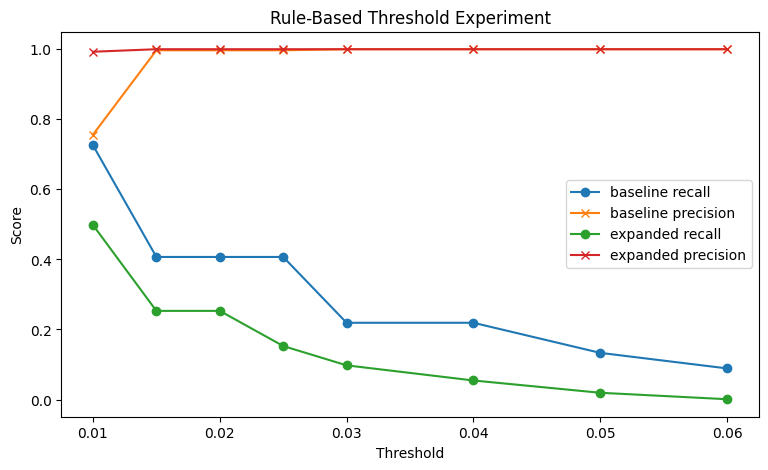

In [15]:
plt.figure(figsize=(9, 5))

for rule_set in rule_experiment_results["rule_set"].unique():
    subset = rule_experiment_results[
        rule_experiment_results["rule_set"] == rule_set
    ]

    plt.plot(
        subset["threshold"],
        subset["recall"],
        marker="o",
        label=f"{rule_set} recall",
    )

    plt.plot(
        subset["threshold"],
        subset["precision"],
        marker="x",
        label=f"{rule_set} precision",
    )

plt.title("Rule-Based Threshold Experiment")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.show()

In [16]:
best_expanded_rule_result = expanded_threshold_results.sort_values(
    by=["f1", "recall"],
    ascending=False,
).iloc[0]

best_expanded_rule_result

threshold        0.01
accuracy     0.775963
precision     0.99282
recall       0.498129
f1           0.663407
rule_set     expanded
Name: 0, dtype: object

In [17]:
best_expanded_threshold = best_expanded_rule_result["threshold"]

expanded_rule_outputs = df["clean_text"].apply(
    lambda text: score_with_rules(text, EXPANDED_SCAM_RULES)
)

df["expanded_rule_score"] = expanded_rule_outputs.apply(
    lambda output: output["rule_score"]
)

df["expanded_rule_triggers"] = expanded_rule_outputs.apply(
    lambda output: output["triggered_categories"]
)

df["expanded_rule_prediction"] = df["expanded_rule_score"].apply(
    lambda score: "scam" if score >= best_expanded_threshold else "legitimate"
)

print(f"Best expanded rule threshold: {best_expanded_threshold}")
print(classification_report(df["label"], df["expanded_rule_prediction"], zero_division=0))

Best expanded rule threshold: 0.01
              precision    recall  f1-score   support

  legitimate       0.71      1.00      0.83      9066
        scam       0.99      0.50      0.66      7217

    accuracy                           0.78     16283
   macro avg       0.85      0.75      0.75     16283
weighted avg       0.84      0.78      0.76     16283



In [18]:
rule_comparison_results = pd.DataFrame(
    [
        {
            "model": "Baseline Rule-Based",
            "accuracy": accuracy_score(df["label"], df["rule_prediction"]),
            "precision": precision_score(
                df["label"],
                df["rule_prediction"],
                pos_label="scam",
                zero_division=0,
            ),
            "recall": recall_score(
                df["label"],
                df["rule_prediction"],
                pos_label="scam",
                zero_division=0,
            ),
            "f1": f1_score(
                df["label"],
                df["rule_prediction"],
                pos_label="scam",
                zero_division=0,
            ),
        },
        {
            "model": "Expanded Rule-Based",
            "accuracy": accuracy_score(df["label"], df["expanded_rule_prediction"]),
            "precision": precision_score(
                df["label"],
                df["expanded_rule_prediction"],
                pos_label="scam",
                zero_division=0,
            ),
            "recall": recall_score(
                df["label"],
                df["expanded_rule_prediction"],
                pos_label="scam",
                zero_division=0,
            ),
            "f1": f1_score(
                df["label"],
                df["expanded_rule_prediction"],
                pos_label="scam",
                zero_division=0,
            ),
        },
    ]
)

rule_comparison_results

,model,accuracy,precision,recall,f1
0,Baseline Rule-Based,0.653872,1.00000,0.219066,0.359400
1,Expanded Rule-Based,0.775963,0.99282,0.498129,0.663407


In [19]:
newly_caught_scams = df[
    (df["label"] == "scam")
    & (df["rule_prediction"] == "legitimate")
    & (df["expanded_rule_prediction"] == "scam")
]

newly_caught_scams[
    [
        "text",
        "label",
        "rule_prediction",
        "expanded_rule_prediction",
        "expanded_rule_triggers",
    ]
].head(10)

,text,label,rule_prediction,expanded_rule_prediction,expanded_rule_triggers
5,FreeMsg Hey there darling it's been 3 week's n...,scam,legitimate,scam,"[urgency, sms_patterns]"
12,URGENT! You have won a 1 week FREE membership ...,scam,legitimate,scam,"[urgency, reward_bait, sms_patterns]"
15,"XXXMobileMovieClub: To use your credit, click ...",scam,legitimate,scam,"[action_request, sms_patterns]"
42,07732584351 - Rodger Burns - MSG = We tried to...,scam,legitimate,scam,"[urgency, action_request, sms_patterns]"
65,"As a valued customer, I am pleased to advise y...",scam,legitimate,scam,"[reward_bait, polite_authority]"
67,Urgent UR awarded a complimentary trip to Euro...,scam,legitimate,scam,"[urgency, sms_patterns]"
119,PRIVATE! Your 2004 Account Statement for 07742...,scam,legitimate,scam,"[urgency, reward_bait]"
120,URGENT! Your Mobile No. was awarded £2000 Bonu...,scam,legitimate,scam,"[urgency, reward_bait]"
133,Sunshine Quiz Wkly Q! Win a top Sony DVD playe...,scam,legitimate,scam,"[urgency, sms_patterns]"
134,Want 2 get laid tonight? Want real Dogging loc...,scam,legitimate,scam,[sms_patterns]


In [20]:
new_false_positives = df[
    (df["label"] == "legitimate")
    & (df["rule_prediction"] == "legitimate")
    & (df["expanded_rule_prediction"] == "scam")
]

new_false_positives[
    [
        "text",
        "label",
        "rule_prediction",
        "expanded_rule_prediction",
        "expanded_rule_triggers",
    ]
].head(10)

,text,label,rule_prediction,expanded_rule_prediction,expanded_rule_triggers
55,Do you know what Mallika Sherawat did yesterda...,legitimate,legitimate,scam,"[urgency, url_prescence]"
200,Hello darlin ive finished college now so txt m...,legitimate,legitimate,scam,"[urgency, sms_patterns]"
432,"Hi hope u get this txt~journey hasnt been gd,n...",legitimate,legitimate,scam,"[urgency, sms_patterns]"
487,Are you free now?can i call now?,legitimate,legitimate,scam,"[urgency, action_request]"
500,You should know now. So how's anthony. Are you...,legitimate,legitimate,scam,"[urgency, emotional_manipulation]"
830,I am in office:)whats the matter..msg me now.i...,legitimate,legitimate,scam,"[urgency, sms_patterns]"
898,"When people see my msgs, They think Iam addict...",legitimate,legitimate,scam,"[urgency, sms_patterns]"
936,Sorry i now then c ur msg... Yar lor so poor t...,legitimate,legitimate,scam,"[urgency, sms_patterns]"
1138,Msgs r not time pass.They silently say that I ...,legitimate,legitimate,scam,"[urgency, sms_patterns]"
1503,In e msg jus now. U said thanks for gift.,legitimate,legitimate,scam,"[urgency, sms_patterns]"


The expanded rule experiment demonstrates how symbolic systems can be improved through linguistic error analysis. By adding categories such as account notifications, credential flows, billing issues, delivery language, link framing, and QR or attachment cues, the rule-based system can capture more scam messages that were missed by the original rules.

However, this also introduces a precision-recall trade-off. Broader rules may improve recall by detecting more scams, but they may also increase false positives by flagging legitimate messages that use similar business or service language.

This supports the larger argument of the project: rule-based systems are interpretable and tunable, but their performance depends heavily on the coverage and quality of handcrafted linguistic rules.

## 6. BERT-Based Contextual Model

The BERT-based model represents a machine-learned approach to language understanding.

Unlike the rule-based system, it does not rely on handcrafted scam keywords. Instead, it evaluates the full text and uses contextual relationships between words to estimate whether a message appears suspicious.

In this version, a pretrained DistilBERT model is used as a proxy baseline. This model is not specifically trained for scam detection, but it demonstrates where contextual language modeling fits in the overall pipeline.

In [21]:
from transformers import pipeline

bert_baseline = pipeline(
    "text-classification",
    model="distilbert-base-uncased-finetuned-sst-2-english",
)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [22]:
def bert_proxy_score(text):
    """Create a temporary scam-risk proxy score using a pretrained BERT model.

    Notes
    -----
    This is not a final scam-specific classifier. It uses a sentiment-trained
    DistilBERT model as a placeholder contextual baseline until BERT is fine-tuned
    on scam-specific text.

    Parameters
    ----------
    text : str
        Input message.

    Returns
    -------
    float
        Approximate scam-risk score between 0 and 1.
    """
    result = bert_baseline(text[:512])[0]

    label = result["label"]
    score = result["score"]

    if label == "NEGATIVE":
        return score

    return 1 - score

In [23]:
df["bert_score"] = df["text"].apply(bert_proxy_score)

df[["text", "label", "bert_score"]]

,text,label,bert_score
0,"Go until jurong point, crazy.. Available only ...",legitimate,0.991627
1,Ok lar... Joking wif u oni...,legitimate,0.991195
2,Free entry in 2 a wkly comp to win FA Cup fina...,scam,0.982790
3,U dun say so early hor... U c already then say...,legitimate,0.995092
4,"Nah I don't think he goes to usf, he lives aro...",legitimate,0.996230
...,...,...,...
16278,Your monthly statement is now available in you...,legitimate,0.909225
16279,Your appointment confirmation has been updated.,legitimate,0.043487
16280,Your package delivery status changed this morn...,legitimate,0.992916
16281,Your password was changed successfully.,legitimate,0.000858


In [24]:
def bert_predict(score, threshold=0.50):
    """Predict scam or legitimate using the BERT proxy score.

    Parameters
    ----------
    score : float
        Approximate scam-risk score from the BERT proxy model.
    threshold : float, default=0.50
        Minimum score required to classify a message as scam.

    Returns
    -------
    str
        Predicted label.
    """
    return "scam" if score >= threshold else "legitimate"


df["bert_prediction"] = df["bert_score"].apply(bert_predict)

df[["text", "label", "bert_score", "bert_prediction"]]

,text,label,bert_score,bert_prediction
0,"Go until jurong point, crazy.. Available only ...",legitimate,0.991627,scam
1,Ok lar... Joking wif u oni...,legitimate,0.991195,scam
2,Free entry in 2 a wkly comp to win FA Cup fina...,scam,0.982790,scam
3,U dun say so early hor... U c already then say...,legitimate,0.995092,scam
4,"Nah I don't think he goes to usf, he lives aro...",legitimate,0.996230,scam
...,...,...,...,...
16278,Your monthly statement is now available in you...,legitimate,0.909225,scam
16279,Your appointment confirmation has been updated.,legitimate,0.043487,legitimate
16280,Your package delivery status changed this morn...,legitimate,0.992916,scam
16281,Your password was changed successfully.,legitimate,0.000858,legitimate


In [25]:
print("BERT Proxy Model Evaluation")
print(classification_report(df["label"], df["bert_prediction"], zero_division=0))

BERT Proxy Model Evaluation
              precision    recall  f1-score   support

  legitimate       0.84      0.61      0.70      9066
        scam       0.63      0.85      0.73      7217

    accuracy                           0.72     16283
   macro avg       0.74      0.73      0.72     16283
weighted avg       0.75      0.72      0.71     16283



## 7. Hybrid Model

The hybrid model combines the expanded rule-based linguistic score with the BERT-based contextual score. This approach is designed to integrate explicit symbolic patterns with broader contextual understanding.

Rather than relying solely on predefined rules or learned representations, the hybrid model attempts to leverage both sources of information to improve detection coverage.

The goal of this approach is to evaluate whether combining symbolic and contextual signals leads to improved performance compared to each method individually. However, as shown in the results, simple weighted combination does not necessarily yield substantial performance gains, highlighting the challenges of effectively integrating these approaches.

In [26]:
def hybrid_score(rule_score, bert_score, rule_weight=0.4, bert_weight=0.6):
    """Combine rule-based and BERT-based scores.

    Parameters
    ----------
    rule_score : float
        Score from rule-based model.
    bert_score : float
        Score from BERT proxy model.
    rule_weight : float
        Weight for rule-based score.
    bert_weight : float
        Weight for BERT score.

    Returns
    -------
    float
        Combined hybrid score.
    """
    return (rule_weight * rule_score) + (bert_weight * bert_score)

In [27]:
df["hybrid_score"] = df.apply(
    lambda row: hybrid_score(row["expanded_rule_score"], row["bert_score"]),
    axis=1
)

df[["text", "label", "expanded_rule_score", "bert_score", "hybrid_score"]]

,text,label,expanded_rule_score,bert_score,hybrid_score
0,"Go until jurong point, crazy.. Available only ...",legitimate,0.000000,0.991627,0.594976
1,Ok lar... Joking wif u oni...,legitimate,0.000000,0.991195,0.594717
2,Free entry in 2 a wkly comp to win FA Cup fina...,scam,0.007463,0.982790,0.592659
3,U dun say so early hor... U c already then say...,legitimate,0.000000,0.995092,0.597055
4,"Nah I don't think he goes to usf, he lives aro...",legitimate,0.000000,0.996230,0.597738
...,...,...,...,...,...
16278,Your monthly statement is now available in you...,legitimate,0.007463,0.909225,0.548520
16279,Your appointment confirmation has been updated.,legitimate,0.000000,0.043487,0.026092
16280,Your package delivery status changed this morn...,legitimate,0.014925,0.992916,0.601720
16281,Your password was changed successfully.,legitimate,0.000000,0.000858,0.000515


In [28]:
def hybrid_predict(score, threshold=0.35):
    """Predict scam or legitimate using hybrid score."""
    return "scam" if score >= threshold else "legitimate"


df["hybrid_prediction"] = df["hybrid_score"].apply(hybrid_predict)

df[["text", "label", "hybrid_score", "hybrid_prediction"]]

,text,label,hybrid_score,hybrid_prediction
0,"Go until jurong point, crazy.. Available only ...",legitimate,0.594976,scam
1,Ok lar... Joking wif u oni...,legitimate,0.594717,scam
2,Free entry in 2 a wkly comp to win FA Cup fina...,scam,0.592659,scam
3,U dun say so early hor... U c already then say...,legitimate,0.597055,scam
4,"Nah I don't think he goes to usf, he lives aro...",legitimate,0.597738,scam
...,...,...,...,...
16278,Your monthly statement is now available in you...,legitimate,0.548520,scam
16279,Your appointment confirmation has been updated.,legitimate,0.026092,legitimate
16280,Your package delivery status changed this morn...,legitimate,0.601720,scam
16281,Your password was changed successfully.,legitimate,0.000515,legitimate


In [29]:
print("Hybrid Model Evaluation")
print(classification_report(df["label"], df["hybrid_prediction"], zero_division=0))

Hybrid Model Evaluation
              precision    recall  f1-score   support

  legitimate       0.83      0.61      0.71      9066
        scam       0.63      0.84      0.72      7217

    accuracy                           0.71     16283
   macro avg       0.73      0.73      0.71     16283
weighted avg       0.74      0.71      0.71     16283



## 8. Evaluation

This section compares the expanded rule-based, BERT proxy, and hybrid models

The evaluation includes:

- accuracy
- precision
- recall
- F1-score
- confusion matrices
- disagreement analysis

This helps show not only which model performs best, but also where the models differ in how they classify scam language.

In [30]:
def get_metrics(y_true, y_pred, model_name):
    """Calculate classification metrics for one model.

    Parameters
    ----------
    y_true : list-like
        True labels.
    y_pred : list-like
        Predicted labels.
    model_name : str
        Name of the evaluated model.

    Returns
    -------
    dict
        Dictionary containing accuracy, precision, recall, and F1-score.
    """
    return {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, pos_label="scam", zero_division=0),
        "recall": recall_score(y_true, y_pred, pos_label="scam", zero_division=0),
        "f1": f1_score(y_true, y_pred, pos_label="scam", zero_division=0),
    }


results = pd.DataFrame([
    get_metrics(df["label"], df["expanded_rule_prediction"], "Expanded Rule-Based"),
    get_metrics(df["label"], df["bert_prediction"], "BERT Proxy"),
    get_metrics(df["label"], df["hybrid_prediction"], "Hybrid"),
])

results.sort_values(by="f1", ascending=False)

,model,accuracy,precision,recall,f1
1,BERT Proxy,0.715716,0.632963,0.853540,0.726887
2,Hybrid,0.714856,0.634511,0.841208,0.723384
0,Expanded Rule-Based,0.775963,0.992820,0.498129,0.663407


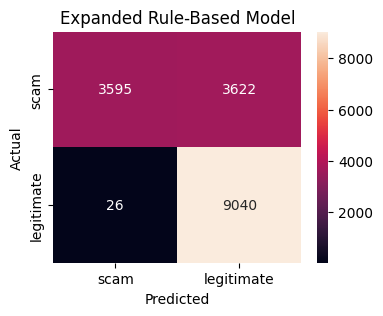

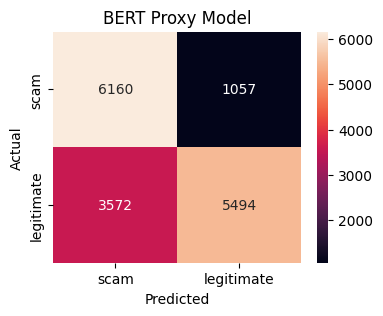

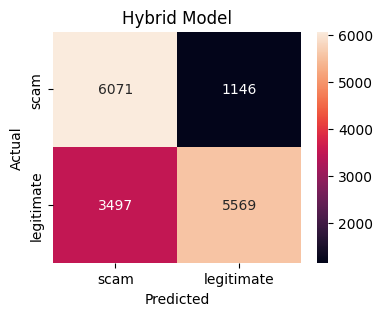

In [31]:
def plot_confusion(y_true, y_pred, title):
    """Plot a confusion matrix for scam classification results."""
    cm = confusion_matrix(y_true, y_pred, labels=["scam", "legitimate"])

    plt.figure(figsize=(4, 3))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=["scam", "legitimate"],
        yticklabels=["scam", "legitimate"],
    )
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


plot_confusion(df["label"], df["expanded_rule_prediction"], "Expanded Rule-Based Model")
plot_confusion(df["label"], df["bert_prediction"], "BERT Proxy Model")
plot_confusion(df["label"], df["hybrid_prediction"], "Hybrid Model")

In [32]:
df["disagreement"] = (
    (df["expanded_rule_prediction"] != df["bert_prediction"]) |
    (df["expanded_rule_prediction"] != df["hybrid_prediction"]) |
    (df["bert_prediction"] != df["hybrid_prediction"])
)

df[df["disagreement"]][[
    "text",
    "label",
    "expanded_rule_prediction",
    "bert_prediction",
    "hybrid_prediction",
    "expanded_rule_triggers",
]]

,text,label,expanded_rule_prediction,bert_prediction,hybrid_prediction,expanded_rule_triggers
0,"Go until jurong point, crazy.. Available only ...",legitimate,legitimate,scam,scam,[]
1,Ok lar... Joking wif u oni...,legitimate,legitimate,scam,scam,[]
2,Free entry in 2 a wkly comp to win FA Cup fina...,scam,legitimate,scam,scam,[sms_patterns]
3,U dun say so early hor... U c already then say...,legitimate,legitimate,scam,scam,[]
4,"Nah I don't think he goes to usf, he lives aro...",legitimate,legitimate,scam,scam,[]
...,...,...,...,...,...,...
16267,You have won a Nokia 7250i. This is what you g...,scam,scam,legitimate,legitimate,"[urgency, reward_bait]"
16268,Records indicate you were involved in an accid...,scam,legitimate,scam,legitimate,[sms_patterns]
16270,Yes :)it is completely in out of form:),legitimate,legitimate,scam,scam,[]
16277,"Congratulations, you have won a prize. Click t...",scam,scam,legitimate,legitimate,"[reward_bait, action_request]"


In [33]:
prediction_counts = pd.DataFrame({
    "Expanded Rule-Based": df["expanded_rule_prediction"].value_counts(),
    "BERT Proxy": df["bert_prediction"].value_counts(),
    "Hybrid": df["hybrid_prediction"].value_counts(),
})

prediction_counts

,Expanded Rule-Based,BERT Proxy,Hybrid
legitimate,12662,6551,6715
scam,3621,9732,9568


In [34]:
results.sort_values(by="f1", ascending=False)

,model,accuracy,precision,recall,f1
1,BERT Proxy,0.715716,0.632963,0.853540,0.726887
2,Hybrid,0.714856,0.634511,0.841208,0.723384
0,Expanded Rule-Based,0.775963,0.992820,0.498129,0.663407


## 9. Results and Discussion

The models were evaluated on a combined dataset of 16,283 messages drawn from SMS spam, phishing emails, and smishing datasets. The dataset is relatively balanced, allowing for meaningful comparison across models.

The initial rule-based model achieved perfect precision but very low recall, indicating that it only identified scams when highly explicit linguistic cues were present. After the targeted rule improvement experiment, the expanded rule-based system significantly increased recall from approximately 0.19 to 0.50 while maintaining very high precision (approximately 0.99). This demonstrates that symbolic systems can be systematically improved through linguistic analysis and rule expansion.

The BERT-based model achieved the highest recall (approximately 0.85) and the strongest overall F1-score (approximately 0.73), indicating its ability to capture contextual patterns that extend beyond predefined rules. However, its lower precision compared to the rule-based model suggests that it produces more false positives, likely due to its reliance on general language patterns rather than domain-specific training.

The hybrid model combines the expanded rule-based and BERT-based scores. While this approach integrates both symbolic and contextual signals, it does not significantly outperform the BERT model. Instead, it produces similar performance, suggesting that simple weighted score combination is not sufficient to fully leverage the strengths of both approaches.

Disagreement analysis highlights that the models often classify messages differently. The expanded rule-based system captures explicit linguistic indicators with high reliability, while BERT captures broader contextual cues but may overgeneralize. These differences reinforce the idea that symbolic and neural models represent language in fundamentally different ways.

Overall, the results demonstrate that symbolic and contextual approaches provide complementary strengths. Rule-based systems offer interpretability and precision, while contextual models provide broader coverage. Hybrid systems show promise but require more advanced integration methods to achieve meaningful performance gains.

## 10. Limitations

This project has several limitations that affect the interpretation of the results.

First, the dataset is constructed from multiple public sources with differing labeling standards. This may introduce inconsistencies in how scam and legitimate messages are defined across datasets.

Second, the BERT model used in this project is not fine-tuned for scam detection. It is a pretrained sentiment classification model, which limits its ability to fully capture domain-specific patterns and contributes to false positives.

Third, although the expanded rule-based system improves recall, it also introduces ambiguity. Legitimate messages may contain language that overlaps with scam indicators such as urgency or action requests, resulting in false positives. This highlights the difficulty of capturing intent using purely symbolic rules.

Additionally, the hybrid model relies on a simple weighted combination of rule-based and BERT-based scores. While this provides a useful comparison, it does not significantly outperform the BERT model, suggesting that more advanced ensemble methods or integration strategies are needed.

Future work could address these limitations by fine-tuning transformer models on scam-specific data, improving dataset consistency, and developing more sophisticated hybrid architectures that better integrate symbolic and contextual representations.